In [86]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [87]:
model=ChatOllama(model='llama3.2')

In [88]:
class State(TypedDict):
    name :str
    cleaned_name:str
    greeting :str

In [89]:
def clean_name(state:State):
    cleaned=state['name'].title()

    return{
        "cleaned_name":cleaned
    }

In [90]:
def genrate_greeting(state: State):
    greeting_str = (
        f"Hello {state['cleaned_name']}, "
        f"welcome to AI Lab!"
    )

    return {
        "greeting": greeting_str
    }

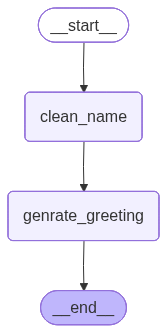

In [91]:
Graph1=StateGraph(State)
Graph1.add_node("clean_name",clean_name)
Graph1.add_node("genrate_greeting",generate_greeting)
Graph1.add_edge(START,'clean_name')
Graph1.add_edge('clean_name','genrate_greeting')
Graph1.add_edge('genrate_greeting',END)
# Graph1.compile()
graph=Graph1.compile()
graph


In [93]:
state = {
    "name": "john smith",
    "cleaned_name": "John Smith"
}

print(genrate_greeting(state))

{'greeting': 'Hello John Smith, welcome to AI Lab!'}


In [92]:
graph.invoke({"name": "john smith"})

KeyError: <function clean_name at 0x0000019781B1E6C0>

In [ ]:
state = {
    "name": "john smith",
    "cleaned_name": "John Smith"
}

print(genrate_greeting(state))

KeyError: <function clean_name at 0x0000019781D5C040>